<a href="https://colab.research.google.com/github/Bereza-Aleks/ML_course/blob/main/HW_Module_2/Part_1/HW_2_1_%D0%90%D0%BD%D0%B0%D0%BB%D1%96%D0%B7_%D0%BE%D0%B7%D0%BD%D0%B0%D0%BA_%D0%B4%D0%BB%D1%8F_%D0%BF%D0%BE%D0%B1%D1%83%D0%B4%D0%BE%D0%B2%D0%B8_%D0%BB%D1%96%D0%BD%D1%96%D0%B8%CC%86%D0%BD%D0%BE%D1%97_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%96%D1%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [153]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
%matplotlib inline
import pandas as pd
import numpy as np


**Завдання 1**: Завантажте дані `medical-charges.csv` в пандас датафрейм і виведіть перші 5 записів. Напишіть, як ви можете підійти до вирішення задачі прогнозування колонки `charges` на основі інших колонок виходячи з наявних на даний момент знань (без ML методів, чисто з використанням аналітики). Запишіть 3 або більше ідей, які приходять вам на думку нижче:

In [154]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [155]:
medical_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/2.1 a b tests/Data_files/medical-charges.csv')

In [156]:
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Ідеї:
1) Погрупувати по каттегоріям (пр. курці\не курці, чи мають дітей, регіон, стать) визначити середнє по оплаті для кожної групи, проаналізувати хто більше платить

2) перевірити залежність між кожною колонкою та оплатою, визначити що впливає найбільше на оплату (де найбільша кореляція).
Де колонка має найбільшу кореляцію - то їй поставимо найбільшу вагу, яку використати для створення формули по обчисленнню оплати за страхування.

3) побудувати графік (боксплот як варіант) для порівняння категорій, щоб візуально побачити яка категорія платить більше

**Завдання 2**: Візуалізуйте розподіл медичних зборів (`charges`) у вигляді інтерактивної гістограми plotly з розбиттями за категоріями ознак
1. `sex`
2. `region`

Додайте маржинальний графік у вигляді бокс-плота вгорі по дикретним категоріям ознак.
Скористайтесь прикладом візуалізації з лекції.
Опишіть свої спостереження.

In [157]:
fig = px.histogram(medical_df,
                   x='sex',
                   marginal='box',
                   nbins=3,
                   title='Distribution of sex')
fig.update_layout(bargap=0.1)
fig.show()

In [158]:
fig = px.histogram(
    medical_df,
    x='charges',
    color= 'sex',
    color_discrete_sequence=['blue', 'red'],
    marginal='box',
    nbins=50,
    barmode='group',
    title='Distribution medical charges by sex'
)
fig.update_layout(bargap=0.25)
fig.show()

Висновок:

З огляду на Distribution of sex розподіл за статтю є рівномірний, кількість жінок і чоловіків у даній вибірці майже однакова.

З огляду на Distribution medical charges by sex, бачимо що чоловіки переважають у оплаті страховці від 30к, також очевидно переважають у дешевих страхових опціях (від 0 - 2000).

Жінок більше або  рівно в страхавці вартістю від 2000 -20к.
На графіку боксплот можна зауважити що існують викиди, можливо це зумоволено додатковими опціями страхування що підвищують її вартість.

Боксплот графік теж чітко показує, що чоловіки мають більший діапазон вартості страхівки.
Якщо потрібно більше фактів на основі цих даних, було б добре проаналізувати їх відкинувши викиди та окремо проаналізувати причини викидів.

In [159]:
fig = px.histogram(medical_df,
                   x='region',
                   marginal='box',
                   nbins=7,
                   title='Distribution of region')
fig.update_layout(bargap=0.1)
fig.show()

In [160]:
fig = px.histogram(
    medical_df,
    x='charges',
    color='region',
    marginal='box',
    nbins=50,
    barmode='group',
    title='Distribution medical charges by region'
)
fig.update_layout(bargap=0.25)
fig.show()

Висновок:

З огляду на Distribution of region розподіл за region, кількість респондентів з кожного регіону у даній вибірці майже однакова.

З огляду на Distribution medical charges by region, бачимо що southeast регіон має найбільший діапазон (в рамках кв1-кв3). Також 0-2000 та 36к-50к страховки переважають саме в цьому регіоні.

Страхівка 10к-12к переважає у регіоні Southwest. Не враховуючи викидів, в цьому районі стисліший діапазон цін на страхівку порівняно з іншими.

Northwest лідирує по страхівкам 2000-4000, 6000-8000 та 28к-34к.
Notheast - 12к-18к, 20к-26к.

**Завдання 3**: Візуалізуйте з `plotly` розподіл кожного з настуних стовпців відносно того, чи є людина курцем (`smoker`)
- `region`
- `children`

та опишіть коротко свої спостереження.

In [161]:
fig = px.histogram(
    medical_df,
    x='region',
    color='smoker',
    barmode='group',
    title='Розподіл регіонів залежно від того, чи є людина курцем'
)
fig.show()

Висновок:
У кожному з регіонів к-сть тих що не курять преважає тих хто курить. Регіон не виглядає фактором, що впливає на ймовірність куріння. Пропорції курців у різних регіонах схожі.

In [162]:
fig = px.histogram(
    medical_df,
    x='children',
    color='smoker',
    barmode='group',
    title='Кількість курців і некурців залежно від кількості дітей'
)
fig.show()

Висновок:

У кожній категорії по кількості дітей кількість некурців більша.

Нема очевидної залежності між кількістю дітей та чи людина курить.


**Завдання 4**: Візуалізуйте звʼязок між стовпцем `charges` та `children` використовуючи графіки-скрипки (`px.violin`). Опишіть свої спостереження.

In [163]:
fig = px.violin(
    medical_df,
    x='children',
    y='charges',
    box=True,
    title='Розподіл медичних витрат залежно від кількості дітей'
)
fig.show()

У всіх категоріях (від 0 до 5 дітей) медіана витрат подібна,тому наявність дітей не має суттєвого впливу на середній рівень витрат.

У категорії children = 0 видно найбільший діапазон значень, включно з багатьма дуже високими витратами (>60,000).

Стислий розподіл у групі з 5 дітьми, може бути через те, що таких осіб небагато

Для children = 5 — вибірка виглядає меншою, з низькими та меншим діапазоном витрат.

Залежність між children та charges є слабкою.

**Завдання 5.** Розглянемо модель для користувачів, які не є курцями (`no_smoker_df`):

$$charges = w \times age + b$$

Спробуйте 3 різні пари параметрів `w` та `b` аби вручну підігнати лінію під дані використовуючи наведені допоміжні функції `estimate_charges` та `try_parameters`. Опишіть спостереження.
Пари параметрів мають бути НЕ такі, як були наведені в лекції.

In [164]:
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [165]:
def estimate_charges(age, w, b):
    return w * age + b

In [166]:
def try_parameters(df, w, b):
    ages = df.age
    target = df.charges

    estimated_charges = estimate_charges(ages, w, b)

    plt.plot(ages, estimated_charges, 'r', alpha=0.9);
    plt.scatter(ages, target, s=8,alpha=0.8);
    plt.xlabel('Age');
    plt.ylabel('Charges')
    plt.legend(['Estimate', 'Actual']);

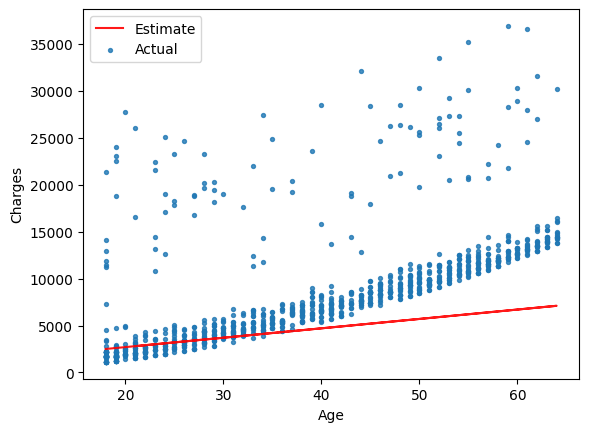

In [167]:
try_parameters(non_smoker_df,100, 700)

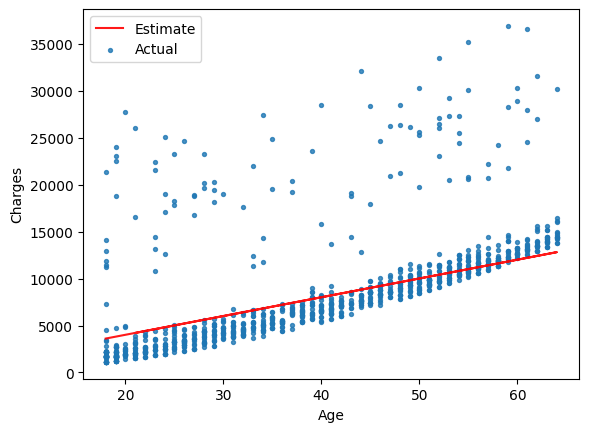

In [168]:
try_parameters(non_smoker_df,200, 10)

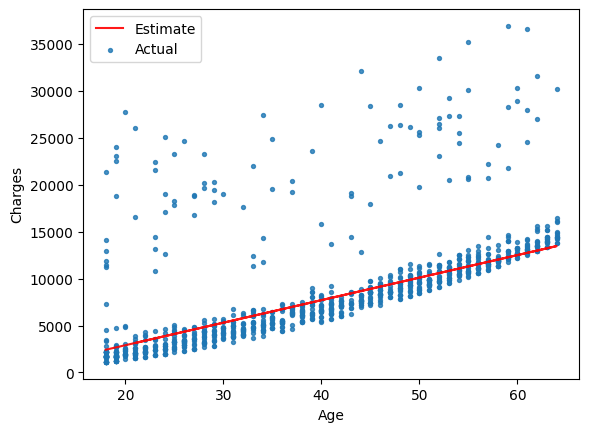

In [169]:
try_parameters(non_smoker_df, 240, -1900)


Для початку підбирала кутовий коефіцієнт w (w>0 так як маємо зростання), а тоді зі зміщенням вверх-вниз - коефіцієнт b.
(Ще як початковий варіант можна взяти точку кластеру що нагадує лінію, підставити відповідні х,у та обчислити b,w)

**Завдання 6**: Напишіть фукнцію для обчислення root mean squared error згідно з формулою цієї метрики точності моделі з використанням `numpy`.

Обчисліть RMSE для тих пар пареметрів, які Ви спробували в завданні 5.

Яке найнижче значення втрат ви зможете досягти? Чи можете ви придумати загальну стратегію для знаходження кращих значень $w$ та $b$ методом проб та помилок?

In [170]:
def rmse(targets,feature, w, b):
    y= w * feature + b
    return np.sqrt(np.mean(np.square(targets - y)))

In [171]:
targets = non_smoker_df['charges']
feature =non_smoker_df.age

In [172]:
medical_df.charges.describe()

,charges
count,1338.000000
mean,13270.422265
std,12110.011237
min,1121.873900
25%,4740.287150
50%,9382.033000
75%,16639.912515
max,63770.428010


In [173]:
rmse(targets, feature, 100,70)

np.float64(6846.089782817806)

In [174]:
rmse(targets, feature, 200, 10)

np.float64(4789.0012098216175)

In [175]:
rmse(targets, feature, 240, -1900)

np.float64(4760.634411262615)

Найкраще значення 4760.63 для параметрів (240,-1900). Підозрюю, що цей показник можна покращити, якщо відкинути викиди і обчислювати лише клестер точок що утворює лінію.

Зі стратегії: 1) дивитися на нахил лінінії, якщо при зростанні х зростає у, то утовий коефіцієнт додатній, якщо маємо обернену залежність - від'ємний
2) коли лінія паралельна осі х, то кутовий коефіцієнт = 0
3) при x=0 прикинути значення у, це і буде коефіцієнт b
4) взяти дві точки через які ми хочемо щоб проходила лінії, скласти систему р-нь з невідомими w and b.